# Stock Market Prediction Using Machine Learning

## Internship Project – DecodeLabs Data Science Internship

### Author: Ernest Amanor Sawer

---

# 1. Introduction

This project focuses on analyzing and predicting stock market prices using Machine Learning techniques.

The project uses historical stock data from Yahoo Finance to:
- understand stock trends,
- perform exploratory data analysis,
- visualize stock movements,
- and build a predictive model.

The stock selected for this project is Tesla (TSLA).

---

# TASK 1 - Collection And Understanding

`yfinance` library will be used to download historical stock market data from Yahoo Finance.

The dataset includes:
- Open price
- Close price
- High price
- Low price
- Volume traded

In [46]:
#libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Downloading Tesla stock data
df = yf.download('TSLA', start='2020-01-01', end='2025-01-01')

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


Dataset Understanding

Here, we explore the structure of the dataset to understand:
- the number of rows and columns,
- data types,
- column names,
- and general dataset information.

This helps understand the quality and structure of the stock market dataset before analysis.

In [3]:
# number of rows and columns
df.shape

(1258, 5)

In [4]:
# column names
df.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [5]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
# statistical summary
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,213.430922,218.283913,208.359167,213.482528,1.255368e+08
std,83.461475,85.396522,81.534697,83.626859,8.208891e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,173.882500,177.230003,170.044994,173.897499,7.601958e+07
50%,220.220001,225.369995,215.343338,220.933334,1.019894e+08
75%,259.932495,264.959175,254.450001,259.270004,1.453064e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [7]:
# saving the dataset
df.to_csv('../data/raw/tesla_stock_data.csv')

**Tesla (TSLA) Stock Data — Dataset Description**

**Overview**
| Property | Details |
|----------|---------|
| Source | Yahoo Finance via `yfinance` library |
| Ticker | TSLA (NASDAQ) |
| Period | January 2020 — January 2025 |
| Trading Days | 1,258 rows |
| Features | 5 columns |

**What the Data Represents**:
This dataset tracks the **daily trading activity of Tesla Inc. (TSLA)**
on the NASDAQ stock exchange over a 5-year period.
Each row represents a single trading day.

**Column Descriptions**:
| Column | Type | Description |
|--------|------|-------------|
| Date | string | The trading date |
| Open | float | Price when the market opened |
| High | float | Highest price reached during the day |
| Low | float | Lowest price reached during the day |
| Close | float | Final price when the market closed |
| Volume | int | Total number of shares traded |


# TASK 2 - Cleaning And Preprocessing

In [8]:
# Loading saved dataset
df = pd.read_csv('../data/raw/tesla_stock_data.csv')

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,28.68400001525879,28.713333129882812,28.11400032043457,28.299999237060547,142981500
3,2020-01-03,29.534000396728516,30.266666412353516,29.128000259399414,29.366666793823242,266677500
4,2020-01-06,30.1026668548584,30.104000091552734,29.333332061767578,29.364667892456055,151995000


In [9]:
# Loading saved dataset ignoring the junk rows and renaming the columns again

df = pd.read_csv("../data/tesla_stock_data.csv", skiprows=[0, 1, 2, 3])
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
1,2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2,2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500
3,2020-01-09,32.089333,33.253334,31.524668,33.139999,426606000
4,2020-01-10,31.876667,32.329334,31.580000,32.119331,194392500


In [10]:
df.isnull().sum

<bound method DataFrame.sum of        Date  Close   High    Low   Open  Volume
0     False  False  False  False  False   False
1     False  False  False  False  False   False
2     False  False  False  False  False   False
3     False  False  False  False  False   False
4     False  False  False  False  False   False
...     ...    ...    ...    ...    ...     ...
1251  False  False  False  False  False   False
1252  False  False  False  False  False   False
1253  False  False  False  False  False   False
1254  False  False  False  False  False   False
1255  False  False  False  False  False   False

[1256 rows x 6 columns]>

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1256 non-null   str    
 1   Close   1256 non-null   float64
 2   High    1256 non-null   float64
 3   Low     1256 non-null   float64
 4   Open    1256 non-null   float64
 5   Volume  1256 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 59.0 KB


In [13]:
# Converting date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1256 non-null   datetime64[us]
 1   Close   1256 non-null   float64       
 2   High    1256 non-null   float64       
 3   Low     1256 non-null   float64       
 4   Open    1256 non-null   float64       
 5   Volume  1256 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 59.0 KB


In [14]:
# Setting Date as index for time series analysis
df.set_index('Date', inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500
2020-01-09,32.089333,33.253334,31.524668,33.139999,426606000
2020-01-10,31.876667,32.329334,31.580000,32.119331,194392500


In [15]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1256 entries, 2020-01-06 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1256 non-null   float64
 1   High    1256 non-null   float64
 2   Low     1256 non-null   float64
 3   Open    1256 non-null   float64
 4   Volume  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [16]:
# Saving cleaned dataset
df.to_csv('../data/processed/cleaned_tesla_stock_data.csv')

In [17]:
df.shape

(1256, 5)

Task 2 Observations:

From the preprocessing stage, the following observations were made:

- The dataset contained no major missing values.
- No duplicate records were identified.
- The Date column was successfully converted into datetime format.
- The Date column was set as the dataset index for time-series analysis.

The dataset is now clean and ready for exploratory data analysis.

# TASK 3 - Exploratory Data Analysis (EDA)

In [18]:
df.describe()

,Close,High,Low,Open,Volume
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,213.724428,218.584540,208.645375,213.776556,1.254105e+08
std,83.202701,85.131042,81.283057,83.367706,8.205606e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,173.980003,177.364998,170.195004,174.055004,7.598032e+07
50%,220.285004,225.574997,215.530006,221.041664,1.019499e+08
75%,260.027489,264.985008,254.614166,259.334175,1.450842e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [19]:
# highest closing price
df['Close'].max()

np.float64(479.8599853515625)

In [20]:
#lowest closing price
df['Close'].min()

np.float64(24.08133316040039)

In [21]:
# average closing price
df['Close'].mean()

np.float64(213.7244278033068)

In [22]:
# average trading volume
df['Volume'].mean()

np.float64(125410530.0955414)

In [23]:
# highest trading volume
df['Volume'].max()

np.int64(914082000)

In [24]:
# Correlation matrix
df.corr()

,Close,High,Low,Open,Volume
Close,1.000000,0.998242,0.998489,0.996169,-0.582298
High,0.998242,1.000000,0.998190,0.998644,-0.573452
Low,0.998489,0.998190,1.000000,0.998177,-0.595488
Open,0.996169,0.998644,0.998177,1.000000,-0.584537
Volume,-0.582298,-0.573452,-0.595488,-0.584537,1.000000


**EDA Findings**

From the exploratory analysis, the following observations were made:

- Tesla stock prices showed significant variation over time.
- Trading volume fluctuated across different trading periods.
- Stock price features such as Open, High, Low, and Close showed strong positive correlations.
- The dataset demonstrated characteristics of a volatile growth stock.


# TASK 4 - Data Visualization 

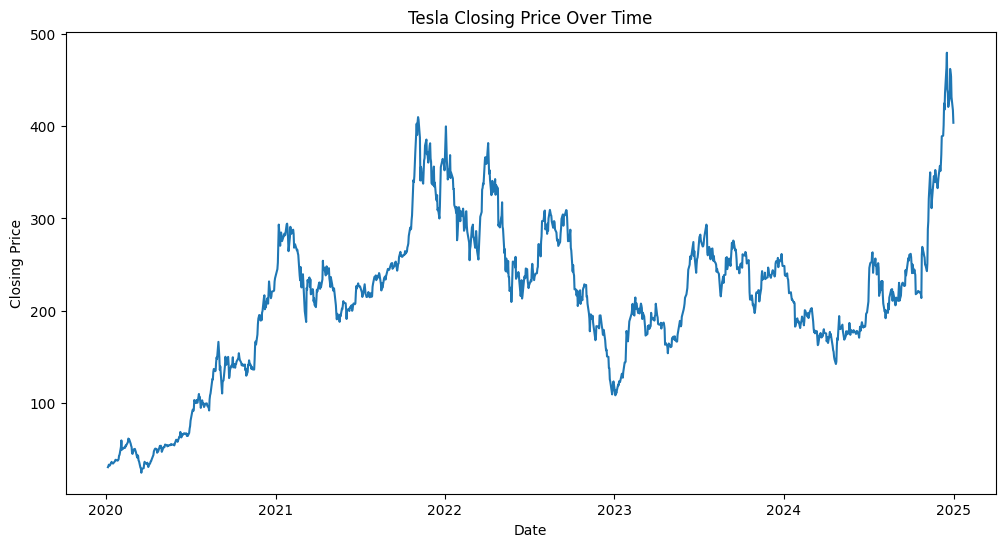

In [27]:
# Tesla Closing Price Trend
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title('Tesla Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.savefig('../images/closing_price_trend.png', bbox_inches='tight')

plt.show()

This visualization shows how Tesla's stock price changed over time.

**Observation**

**Strong Long-term growth**
- Tesla's closing price increased significantly from 2020 to 2025 starting below $50 reaching above $450.

**High volatility**
-  Multiple sharp rises and declines were noticed also the large fluctuations indicate Tesla is a volatile stock.

**Major decline around 2022-2023**
- Stock dropped significantly after reaching peaks above $400 showing periods of market uncertainty and correction.

**Strong Recovery**
- A susbstantial upward movement was experienced towards the end of the period suggesting renewed investor confidence and strong market performance.


Overall, Tesla displayed characteristics of a high-growth and highly volatile stock.

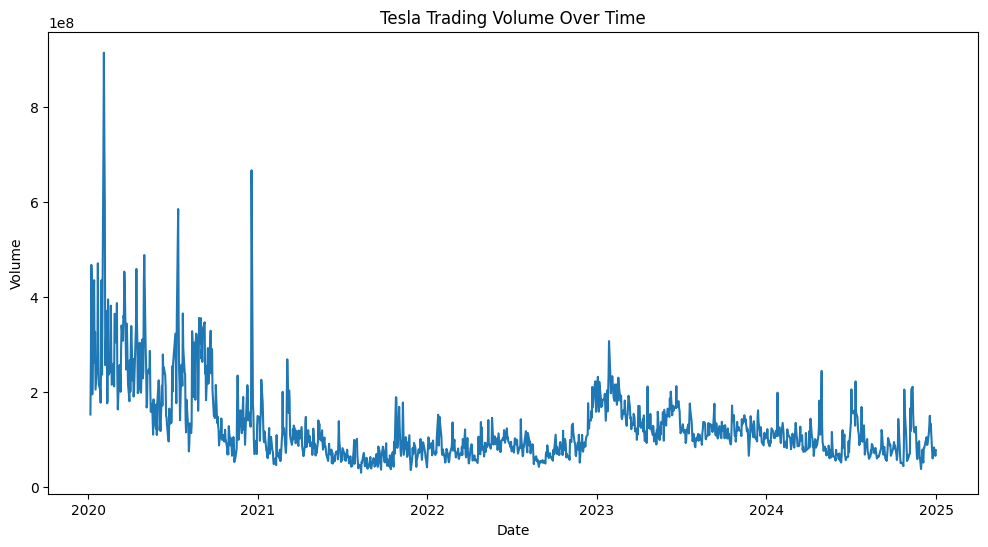

In [28]:
# Trading Volume Trend
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Volume'])

plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.savefig('../images/trading_volume_trend.png', bbox_inches='tight')

plt.show()

Trading volume represents the number of shares traded during a trading day.

**Trading Volume Analysis -- Observations**

**Very high volume in 2020**
- Trading activitay was extremely high at the beginning of the period also large spikes indicating intense investor interest.

**Volume gradually decreased**
- Average trading volume reduced over time and Investors traded fewer shares daily compared to the early years.

**Periodic spikes remained**
- Sudden volume increases still occurred
- Spikes may correspond to earnings announcements, major company news, or market events.

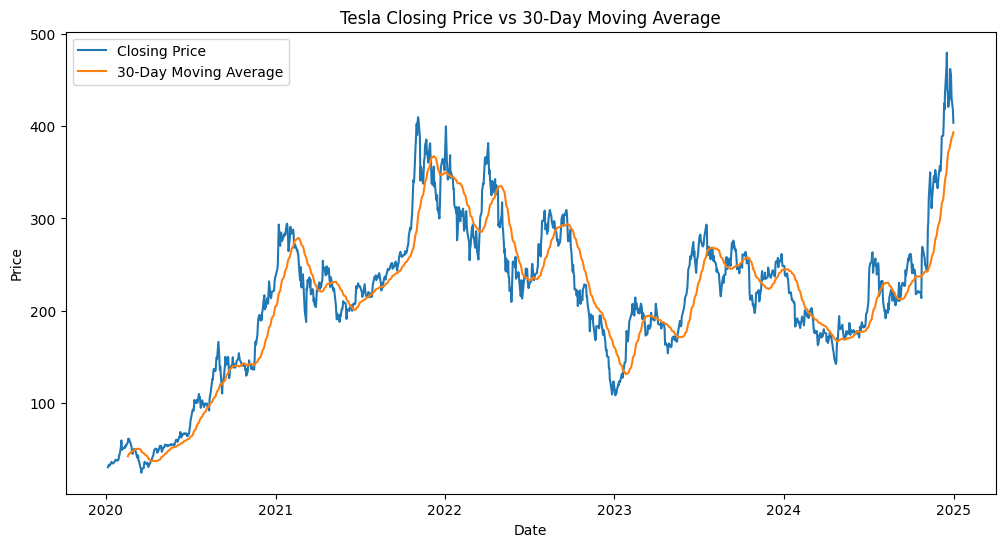

In [29]:
# Moving Average Analysis

# Creating 30-day moving average
df['MA_30'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Closing Price')
plt.plot(df.index, df['MA_30'], label='30-Day Moving Average')

plt.title('Tesla Closing Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.savefig('../images/moving_average_analysis.png', bbox_inches='tight')

plt.show()

**Observation** 

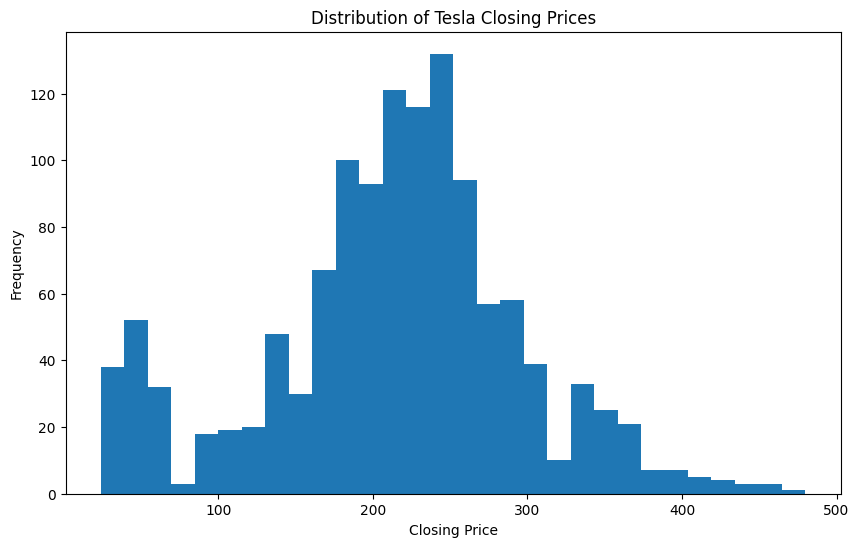

In [30]:
# Distribution of Closing Prices
plt.figure(figsize=(10,6))

plt.hist(df['Close'], bins=30)

plt.title('Distribution of Tesla Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.savefig('../images/distribution_of_closing_prices.png', bbox_inches='tight')
plt.show()

**Observation** 

**Bimodal-like distribution**
- Two distinct clusters of closing prices were revealed
- Smaller cluster appears in the $50-$100 range, reflecting the earlier trading period.
- Then the main bulk of data peaks around $220 - $240, representing the most frequently observed price range.

**Right-skewed tail**
- Distribution extends well past $400, indicating periods of elevated prices which are infrequent but significant.

**Multiple market regimes**
- Distribution shape suggests the dataset spans distinct phases of Tesla's market history
- Prices did not follow a single stable distribution over time.

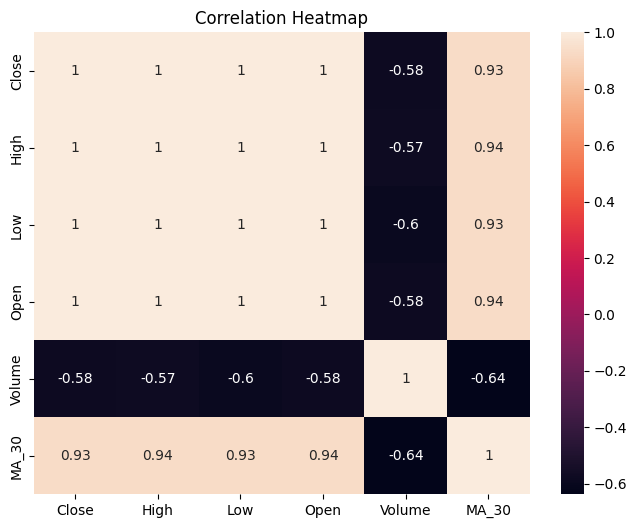

In [32]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title('Correlation Heatmap')

plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Correlation Heatmap -- Observations**

**Perfect correlation among price columns**
- Close, High, Low and Open all show a correlation of 1.0 with each other, indicating severe multicolinearity among the four price features.

**Volume stands apart**
- Volume shows a moderate negative correlation of approximately -0.58 to -0.60 with all price columns meaning higher trading volume generally coincided with lower stock prices.

**Periodic spikes remained**
- The negative volume-price relationship is consistent across all four price metrics making Volume the only feature in the heatmap that carries a meaningfully distinct signal.

In [33]:
# Daily Returns Analysis

# Calculating daily returns
df['Daily_Return'] = df['Close'].pct_change()

df[['Close', 'Daily_Return']].head()

,Close,Daily_Return
Date,,
2020-01-06,30.102667,NaN
2020-01-07,31.270666,0.038801
2020-01-08,32.809334,0.049205
2020-01-09,32.089333,-0.021945
2020-01-10,31.876667,-0.006627


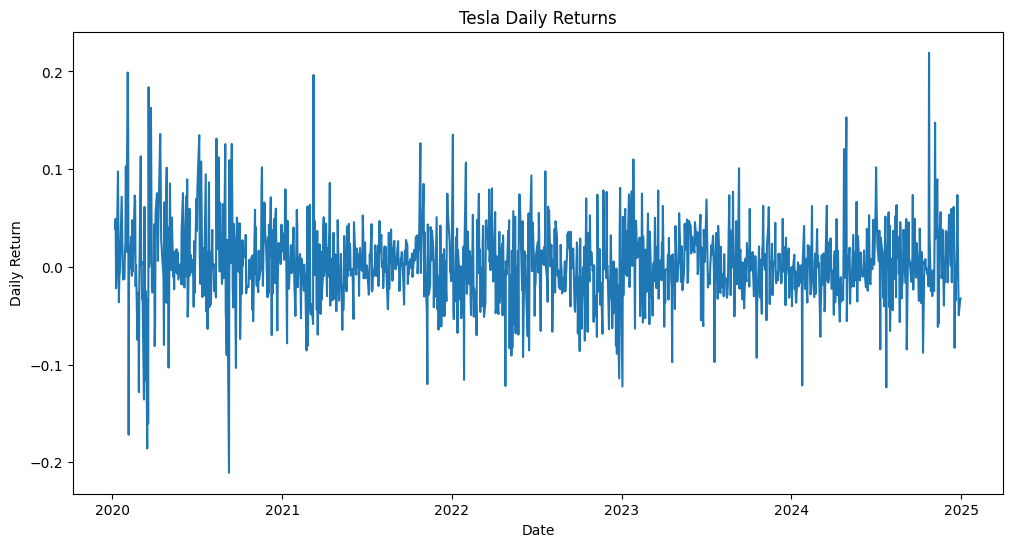

In [34]:
# visualization 
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Daily_Return'])

plt.title('Tesla Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.savefig('../images/daily_returns.png', bbox_inches='tight')

plt.show()

**Daily Returns Analysis -- Observation**

**Returns fluctate around zero**
- Daily returns oscillate consistently above and below the 0.0 baseline throught out the entire period, a typical behaviour for a financial asset, gains and losses alternate unpredictably from day to day.

**Higher volatility in early years (2020–2021)**
- Largerst spikes both positive and negative are concentrated in 2020 and early 2021.
- Returns exceeding +20% and dropping below −20% were observed during this period aligning with Tesla's rapid price appreciation phase and the broader market turbelence of the COVID-19 period.

**Volatility gradually stabilised**
- From mid-2022 onwards, the amplitude of daily swings visibly narrowed also Returns remained mostly within the ±10% range, suggesting a calmer, more mature trading environment.

**Occasional extreme spikes persisted**
- Isolated large spikes continued to appear throughout 2023, 2024, and into 2025 despite the general stabilisation.
- These outliers likely correspond to earnings releases, product announcements, or macroeconomic events.

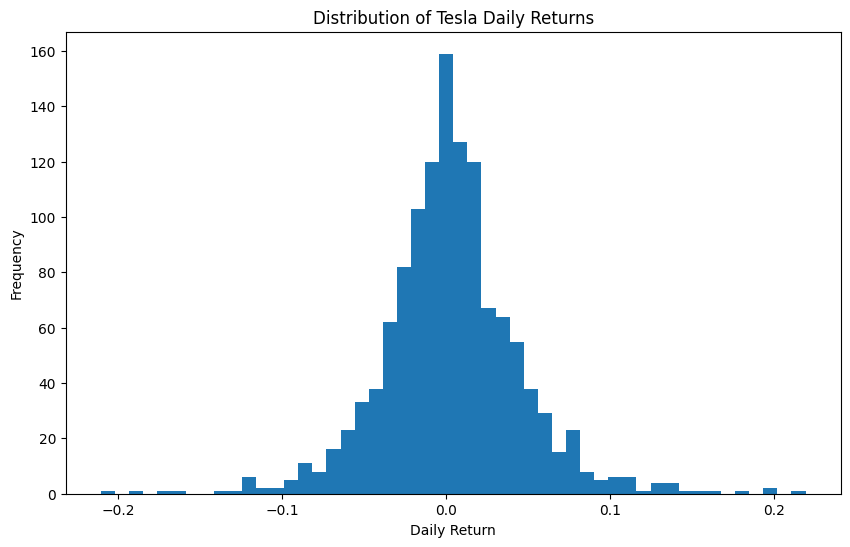

In [35]:
# Distribution of Daily Returns
plt.figure(figsize=(10,6))

plt.hist(df['Daily_Return'].dropna(), bins=50)

plt.title('Distribution of Tesla Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.savefig('../images/distribution_of_daily_returns.png', bbox_inches='tight')

plt.show()

**Distribution of Daily Returns -- Observation**

**Approximately bell-shaped and centred at zero**
- Distribution peaks sharply near 0.0 confirming that the most common daily outcome is a very small gain or loss.
- Overall shape resembles a normal distribution, which is a common assumption in financial modelling.

**Leptokurtic (Fat tails)**
- The fat tails indicate that extreme daily moves occur more frequently than a pure normal distribution would predict, also a well-known property of stock returns called **excess kurtosis**

**Slight asymmetry**
- Distribution appears marginally right-skewed, with a small bump visible around +0.07-0.08 suggesting that large positive single-day gains occurred slightly more often than large negative drops of equivalent magnitude.

**Risk and modelling considerations**
- Fat tails mean rare but extreme events must be acounted for in any prediction model.
- A model that assumes perfectly normal returns will underestimate the probability of large price swings.
- Techniques like standardization, outlier clipping, or robust loss functioins may be necessary during model training. 

**Task 4 Summary**

The visual analysis revealed several important insights:

- Tesla stock demonstrated significant long-term growth.
- The stock experienced substantial volatility throughout the observation period.
- Trading volume fluctuated considerably, with major spikes occurring during periods of heightened market activity.
- Moving averages helped reveal the underlying long-term trend.
- Daily return analysis confirmed the presence of frequent short-term price fluctuations.
- Correlation analysis showed extremely strong relationships among Open, High, Low, and Close prices, while Volume provided a distinct signal.


# TASK 5 - Stock Price Prediction Using Machine Learning

In [36]:
# Defining features for the model training 
X = df[['Open','High','Low','Volume']]

# Defining target for the model training
y =df['Close']

print("Features Shape:", X.shape)
print("Targtet Shape:",y.shape)

Features Shape: (1256, 4)
Targtet Shape: (1256,)


In [38]:
# splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1004, 4)
Testing set: (252, 4)


In [41]:
# Instantiating model
model = LinearRegression()

In [42]:
# Training model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [43]:
# Making predictions for Evaluations
y_pred = model.predict(X_test)

In [44]:
# First 10 predictions vs the actual
print("Predicted Closing Prices:")
print(y_pred[:10])

print("\nActual Closing Prices:")
print(y_test.iloc[:10].values)

Predicted Closing Prices:
[263.91962121  59.57085289  28.95514742  34.23189491 208.44074118
 253.31944262 177.503854   300.51116669 348.056391   198.60359623]

Actual Closing Prices:
[263.78668213  59.87333298  28.50933266  34.41600037 207.66999817
 251.61999512 179.83000183 290.25332642 350.         200.44999695]


In [47]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.3146857061325536
MSE : 10.409969998211253
RMSE: 3.22644851163183
R²  : 0.9986109998954976


The Linear Regression model achieved excellent predictive performance, with an R² score of approximately 99.86%.

However, the model used same-day variables such as High and Low prices to predict the same day's closing price. Since these values are not known before the market closes, the model is not suitable for real-world forecasting.

Despite this limitation, the model effectively demonstrates the machine learning workflow and provides valuable insights into the relationships among stock market variables.

# Stock Forecasting


Predicting the next trading day's closing price using historical information and engineered features.

In [48]:
# Creating the Forecast Target (tomorrow's closing price)
df['Target_Close'] = df['Close'].shift(-1)

df[['Close','Target_Close']].head()

,Close,Target_Close
Date,,
2020-01-06,30.102667,31.270666
2020-01-07,31.270666,32.809334
2020-01-08,32.809334,32.089333
2020-01-09,32.089333,31.876667
2020-01-10,31.876667,34.990665


In [49]:
# Creating lag features 

# yesterday's closing price
df['Lag_1'] =df['Close'].shift(1)

# Closing price from 2 days ago
df['Lag_2'] =df['Close'].shift(2)


df[['Close','Lag_1', 'Lag_2']].head()

,Close,Lag_1,Lag_2
Date,,,
2020-01-06,30.102667,NaN,NaN
2020-01-07,31.270666,30.102667,NaN
2020-01-08,32.809334,31.270666,30.102667
2020-01-09,32.089333,32.809334,31.270666
2020-01-10,31.876667,32.089333,32.809334


In [50]:
# selecting forecasting features
forecast_df = df[
    ['Lag_1','Lag_2', 'MA_30','Daily_Return', 'Volume', 'Target_Close']
].dropna()

forecast_df.head()

,Lag_1,Lag_2,MA_30,Daily_Return,Volume,Target_Close
Date,,,,,,
2020-02-18,53.335335,53.599998,42.006089,0.072960,245725500,61.161331
2020-02-19,57.226665,53.335335,43.041378,0.068756,381345000,59.960667
2020-02-20,61.161331,57.226665,43.997711,-0.019631,264523500,60.066666
2020-02-21,59.960667,61.161331,44.906289,0.001768,214722000,55.585999
2020-02-24,60.066666,59.960667,45.689511,-0.074595,227883000,53.327332


In [51]:
# Using Time-Based Train-Test Split (chronologically instead of randomly )

# Defining forecasting features and target
X_forecast = forecast_df[
    ['Lag_1', 'Lag_2', 'MA_30', 'Daily_Return', 'Volume']
]

y_forecast = forecast_df['Target_Close']

# Determine split point (80% train, 20% test)
split_index = int(len(forecast_df) * 0.8)

# Chronological split
X_train_f = X_forecast.iloc[:split_index]
X_test_f = X_forecast.iloc[split_index:]

y_train_f = y_forecast.iloc[:split_index]
y_test_f = y_forecast.iloc[split_index:]

print("Training set:", X_train_f.shape)
print("Testing set:", X_test_f.shape)

Training set: (980, 5)
Testing set: (246, 5)


In [52]:
# Training the forecasting model

# instantiating the model
forecast_model = LinearRegression()

forecast_model.fit(X_train_f, y_train_f)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
# Predictions

y_pred_f = forecast_model.predict(X_test_f)

print("First 10 Predictions:")
print(y_pred_f[:10])

print("\nActual Values:")
print(y_test_f.iloc[:10].values)

First 10 Predictions:
[236.23767103 234.03467864 228.55625196 220.20571047 219.21300919
 216.1028088  212.15863783 211.8203433  208.88888492 208.74134813]

Actual Values:
[233.94000244 227.22000122 218.88999939 219.91000366 215.55000305
 211.88000488 212.19000244 208.80000305 209.13999939 207.83000183]


In [54]:
# evaluation
mae_f = mean_absolute_error(y_test_f, y_pred_f)
mse_f = mean_squared_error(y_test_f, y_pred_f)
rmse_f = mse_f ** 0.5
r2_f = r2_score(y_test_f, y_pred_f)

print("Forecast MAE :", mae_f)
print("Forecast RMSE:", rmse_f)
print("Forecast R²  :", r2_f)

Forecast MAE : 7.397208560047931
Forecast RMSE: 11.058268358667402
Forecast R²  : 0.9762069042804151


The forecasting model demonstrated strong predictive performance when estimating Tesla's next trading day's closing price using historical information.

The Mean Absolute Error (MAE) of approximately **7.40** indicates that, on average, the model's predictions differed from the actual closing prices by about \$7.40. Considering the wide range of Tesla's stock prices over the study period, this represents a relatively small prediction error.

The Root Mean Squared Error (RMSE) of approximately **11.06** suggests that while the model generally performed well, larger prediction errors occasionally occurred during periods of heightened market volatility. Since RMSE places greater emphasis on larger errors, the difference between the RMSE and MAE values indicates the presence of some extreme market movements that were more difficult to predict accurately.

The model achieved an **R2_score of approximately 97.62%**, meaning that the selected forecasting features were able to explain most of the variation in Tesla's next-day closing prices. This result suggests that historical price behaviour, moving averages, daily returns, and trading activity contain valuable information for short-term stock price forecasting.

Overall, the forecasting model demonstrated that realistic prediction of future stock prices is possible using historical market data, although uncertainty remains due to the inherently volatile nature of financial markets.